#Explainable AI coding project
In this coding project, I will be using a random forest classifier on the breast cancer dataset, and then use two explainable AI measures on it. Afterwards I will compare the actionability of these two explainable AI measures.
##Data handling

In [6]:
# Imports
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Print Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9649122807017544


##SHAP explanations

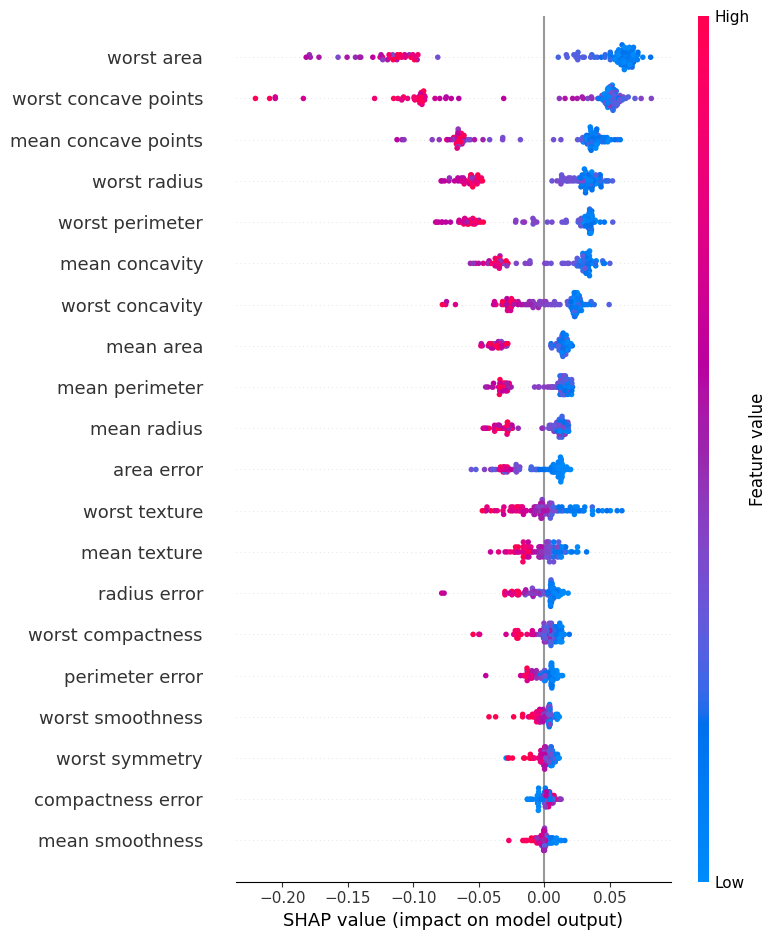

In [7]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test)

# For binary classification → select class 1
shap_values_class1 = shap_values.values[:, :, 1]

shap.summary_plot(shap_values_class1, X_test)

##DiCE counterfactual explanations

In [8]:
import dice_ml
from dice_ml import Dice

# Prepare data for DiCE
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, pd.Series(y_train, name="target")], axis=1),
    continuous_features=X.columns.tolist(),
    outcome_name="target"
)

# Wrap model
dice_model = dice_ml.Model(model=model, backend="sklearn")

# Create explainer
dice = Dice(dice_data, dice_model)

# Pick one instance to explain
instance = X_test.iloc[0:1]

# Generate counterfactuals
cf = dice.generate_counterfactuals(
    instance,
    total_CFs=3,
    desired_class="opposite"
)

cf.visualize_as_dataframe()

100%|██████████| 5/5 [00:03<00:00,  1.39it/s]

Query instance (original outcome : 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,12.47,18.6,81.089996,481.899994,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.639999,96.050003,677.900024,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,1



Diverse Counterfactual set (new outcome: 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,12.47,18.6,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,4013.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,0
1,12.47,18.6,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.64,200.10,3627.7,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,0
2,12.47,18.6,81.09,1913.8,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,2258.8,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,0


...

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,12.4,17.68,81.47,467.8,0.1054,0.1316,0.07741,0.02799,0.1811,0.07102,...,22.91,130.90,3184.0,0.145,0.2629,0.2403,0.0737,0.2556,0.09359,0
1,12.4,17.68,81.47,467.8,0.1054,0.1316,0.07741,0.02799,0.1811,0.07102,...,22.91,89.61,992.5,0.145,0.2629,0.2403,0.2000,0.2556,0.13905,0
2,12.4,17.68,81.47,467.8,0.1054,0.1316,0.07741,0.02799,0.1811,0.07102,...,22.91,202.70,1988.6,0.145,0.2629,0.2403,0.0737,0.2556,0.09359,0


Query instance (original outcome : 1)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,11.54,14.44,74.650002,402.899994,0.09984,0.112,0.06737,0.02594,0.1818,0.06782,...,19.68,78.779999,457.799988,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,1



Diverse Counterfactual set (new outcome: 0)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,11.54,14.44,74.65,402.9,0.09984,0.112,0.06737,0.02594,0.1818,0.06782,...,32.61,78.78,3099.4,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,0
1,11.54,14.44,74.65,402.9,0.09984,0.112,0.06737,0.02594,0.1818,0.06782,...,19.68,248.20,4001.0,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,0
2,11.54,14.44,74.65,402.9,0.09984,0.112,0.06737,0.02594,0.1818,0.06782,...,32.61,78.78,3099.4,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,0


In [9]:
cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

# Remove target column
cf_df = cf_df.drop(columns=["target"])

# Convert original to Series with correct column names
original = instance.iloc[0]

changes = cf_df - original

#printing the difference between the counterfactuals and the original dataset
print(changes)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          0.0           0.0             0.0        0.0              0.0   
1          0.0           0.0             0.0        0.0              0.0   
2          0.0           0.0             0.0     1431.9              0.0   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0               0.0             0.0                  0.0            0.0   
1               0.0             0.0                  0.0            0.0   
2               0.0             0.0                  0.0            0.0   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                     0.0  ...          3.36            0.0             0.00   
1                     0.0  ...          0.00            0.0           104.05   
2                     0.0  ...          0.00            0.0             0.00   

   worst area  worst smoothness  worst compactness  worst concavity  \
0 

##Actionability measures

###Suggested changes

In [11]:
changes = (cf_df - original).abs()
num_changes = (changes > 0.01).sum(axis=1)

print(num_changes)

0    2
1    2
2    2
dtype: int64


###Distance from original

In [13]:
distance = changes.sum(axis=1)
print(distance)

0    3339.36
1    3053.85
2    3012.80
dtype: float64


###Important variables

In [17]:
import numpy as np

# Getting the importance values
shap_vals = np.abs(shap_values_class1)
mean_importance = shap_vals.mean(axis=0)

# Pasting into dataframe for easy view
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": mean_importance
}).sort_values(by="importance", ascending=False)

# print
top_k = importance_df.head(5)
print(top_k)

                 feature  importance
23            worst area    0.076867
27  worst concave points    0.069419
7    mean concave points    0.049093
20          worst radius    0.040511
22       worst perimeter    0.039614
0.6


###SHAP and DiCE agreement

In [ ]:
# Select suggested changes /  high impact variables from both XAI methods
top_features = set(importance_df.head(5)["feature"])
dice_features = set(X.columns[(changes > 0.01).any(axis=0)])

# Find overlap
overlap = top_features.intersection(dice_features)

# Print agreement score
agreement_score = len(overlap) / len(top_features)
print("SHAP and DiCE agreement score: "+ agreement_score)

In these counterfactuals and also